In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.applications.mobilenet_v3 import preprocess_input
from pathlib import Path
import matplotlib.pyplot as plt

I0000 00:00:1776289562.527522   74885 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Data paths and parameters
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32
project_root = Path('/home/groggy/projects/Image-Classification-Explainability')

In [5]:
train_datagen = ImageDataGenerator(
    #rescale=1./224,
    #preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Number of classes: 9
Training samples: 7200
Validation samples: 1800


## Architecture Testing Zone

**Baseline (from previous notebook):**
- GlobalAveragePooling2D → Dense(9, softmax)
- Trainable params: ~4,617
- Best val_accuracy: 0.2589 (25.89%)

**Current Configuration:**
- You can modify the architecture below to test improvements

In [6]:
# Build base model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep frozen for now

print(f"Base model output shape: {base_model.output_shape}")
print(f"Base model has {len(base_model.layers)} layers")

I0000 00:00:1776289567.385123   74885 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1628 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


Base model output shape: (None, 7, 7, 960)
Base model has 187 layers


In [7]:
# EXPERIMENT: Build classifier head
# Modify this architecture to test different configurations

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', name='dense_512')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.3, name='dropout_2')(x)
predictions = Dense(num_classes, activation='softmax', name='predictions')(x)

# Option 3: Add your own architecture here!
# x = Dense(???, activation='relu')(x)
# ...

model = Model(inputs=base_model.input, outputs=predictions)

print(f"\\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

\nTotal parameters: 3,622,025
Trainable parameters: 625,673
Non-trainable parameters: 2,996,352


In [8]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


I0000 00:00:1776289576.857644   74885 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776289582.269260   75288 service.cc:153] XLA service 0x74ab4403ccc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776289582.269302   75288 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776289582.450912   75288 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776289583.893360   75288 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776289584.084140   75288 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10810__.173
E0000 00:00:1776289590.622232   75288 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, 

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7973 - loss: 0.6313

E0000 00:00:1776289689.191490   75289 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776289690.111456   75289 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 426ms/step - accuracy: 0.9244 - loss: 0.2303 - val_accuracy: 0.9772 - val_loss: 0.0506
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 72s 321ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9861 - val_loss: 0.0552
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 66s 294ms/step - accuracy: 0.9940 - loss: 0.0167 - val_accuracy: 0.9828 - val_loss: 0.0566
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 68s 301ms/step - accuracy: 0.9886 - loss: 0.0359 - val_accuracy: 0.9900 - val_loss: 0.0352
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 274ms/step - accuracy: 0.9954 - loss: 0.0122 - val_accuracy: 0.9894 - val_loss: 0.0271
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 273ms/step - accuracy: 0.9942 - loss: 0.0250 - val_accuracy: 0.9661 - val_loss: 0.1250
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 63s 282ms/step - accuracy: 0.9931 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 268ms/step - accuracy: 0.9911 - loss: 0.0318 - va

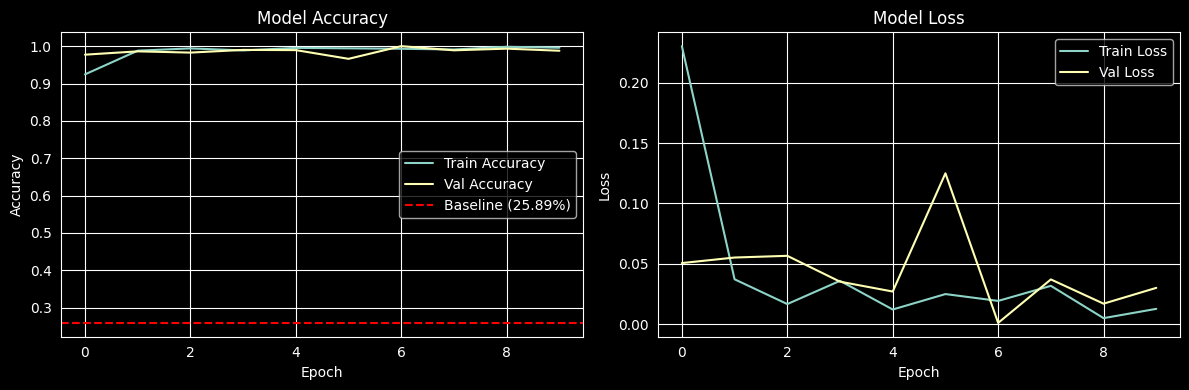

In [14]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=0.2589, color='r', linestyle='--', label='Baseline (25.89%)')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Results summary
best_val_acc = max(history.history['val_accuracy'])
final_val_acc = history.history['val_accuracy'][-1]
baseline_acc = 0.2589

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Baseline validation accuracy:     {baseline_acc:.4f} (25.89%)")
print(f"Current best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final validation accuracy:        {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Improvement over baseline:        {(best_val_acc - baseline_acc):.4f} ({(best_val_acc - baseline_acc)*100:.2f}%)")
print("=" * 60)

if best_val_acc > baseline_acc:
    print("✓ Architecture improved performance!")
else:
    print("✗ No improvement - try different architecture")

RESULTS SUMMARY
Baseline validation accuracy:     0.2589 (25.89%)
Current best validation accuracy: 1.0000 (100.00%)
Final validation accuracy:        0.9878 (98.78%)
Improvement over baseline:        0.7411 (74.11%)
✓ Architecture improved performance!


In [16]:
# Save model if improved
if best_val_acc > baseline_acc:
    save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved.keras'
    model.save(save_path)
    print(f'✓ Model saved to: {save_path}')
else:
    print('Model not saved (no improvement over baseline)')

✓ Model saved to: /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved.keras


In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 4,873,373 (18.59 MB)

 Trainable params: 625,673 (2.39 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

 Optimizer params: 1,251,348 (4.77 MB)